In [1]:
import geopandas as gpd
import geemap
import ee
import xee
import xarray as xr
import os
from glob import glob
import matplotlib.pyplot as plt

In [2]:
# List available cities in mnt/
cities = [d for d in os.listdir('mnt') if os.path.isdir(f'mnt/{d}') and d.startswith('20')]
print("Available cities:")

for i, city in enumerate(sorted(cities), 0):
    print(f"{i}. {city}")


Available cities:
0. 2025-02-tunisia-tunis
1. 2025-10-indonesia-sofifi
2. 2025-10-senegal-dakar
3. 2025-10-senegal-dakar-old
4. 2025-10-senegal-diourbel
5. 2025-10-senegal-matam
6. 2025-10-senegal-matam-old
7. 2025-10-senegal-tambacounda
8. 2025-11-mauritania-nouakchott
9. 2025-11-mauritania-nouakchott-old
10. 2025-11-senegal-thies_region
11. 2025-12-senegal-dagana
12. 2025-12-senegal-dakar
13. 2025-12-senegal-diourbel
14. 2025-12-senegal-kaolack
15. 2025-12-senegal-kedougou
16. 2025-12-senegal-kolda
17. 2025-12-senegal-louga
18. 2025-12-senegal-matam
19. 2025-12-senegal-mbacke
20. 2025-12-senegal-mbour
21. 2025-12-senegal-richard_toll
22. 2025-12-senegal-saint_louis
23. 2025-12-senegal-tambacounda
24. 2025-12-senegal-thies
25. 2025-12-senegal-ziguinchor


In [21]:
# Select city
city_dir = sorted(cities)[2] # Change this to your city

cityname  = city_dir.split('-')[-1] 
data_dir = os.path.join('mnt', city_dir, '02-process-output', 'spatial')
aoi_dir = os.path.join('mnt', city_dir, '01-user-input', 'AOI')
aoi_file = glob(aoi_dir + "/*.shp")[0]

print(f"\n{cityname} - selected: {city_dir}. data_dir: {data_dir}")
print(aoi_file)



dakar - selected: 2025-10-senegal-dakar. data_dir: mnt/2025-10-senegal-dakar/02-process-output/spatial
mnt/2025-10-senegal-dakar/01-user-input/AOI/senegal_dakar.shp


In [ ]:
# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project = USE GEE PROJECT HERE)

In [22]:
aoi = gpd.read_file(aoi_file).to_crs("EPSG:4326")
bounds = aoi.total_bounds  # [minx, miny, maxx, maxy]

# Create EE geometry
AOI = ee.Geometry.Rectangle([bounds[0], bounds[1], bounds[2], bounds[3]])
# AOI = ee.Geometry(aoi_geojson)

In [23]:
print(bounds)
print(AOI.getInfo())

[-17.52983937  14.59047475 -17.11021915  14.8933497 ]
{'type': 'Polygon', 'coordinates': [[[-17.52983936989985, 14.590474751164894], [-17.110219150437175, 14.590474751164894], [-17.110219150437175, 14.89334969534597], [-17.52983936989985, 14.89334969534597], [-17.52983936989985, 14.590474751164894]]]}


In [24]:
hansen = ee.Image("UMD/hansen/global_forest_change_2023_v1_11")

hansen_clipped = hansen.clip(AOI)

ds = xr.open_dataset(
      hansen,
      engine='ee',
      projection=hansen.select('treecover2000').projection(),
      geometry=AOI,
      scale=30
  )

print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 1, 'lon': 1678, 'lat': 1212})


In [25]:
treecover = ds['treecover2000']
treecover.rio.crs

CRS.from_epsg(4326)

In [26]:
treecover = treecover.rio.set_spatial_dims(x_dim='lon', y_dim='lat')
treecover_clipped = treecover.rio.clip(aoi.geometry)

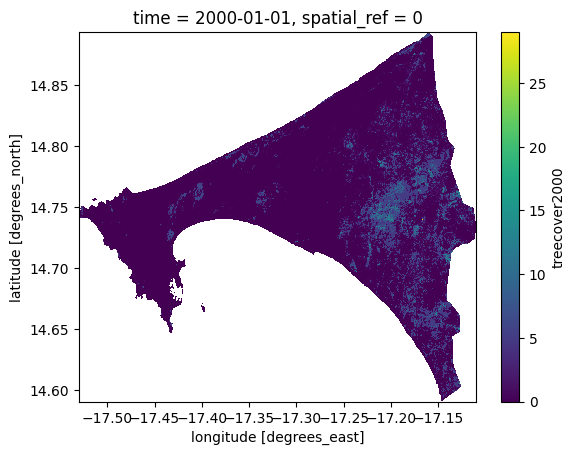

In [ ]:
treecover_clipped.transpose().plot()

In [32]:
treecover_clipped = treecover_clipped.transpose('time', 'lat', 'lon')
treecover_clipped.rio.to_raster("output.tif")